# **Decision Tree from Scratch**

## 0.ライブラリのインポートとデータの生成

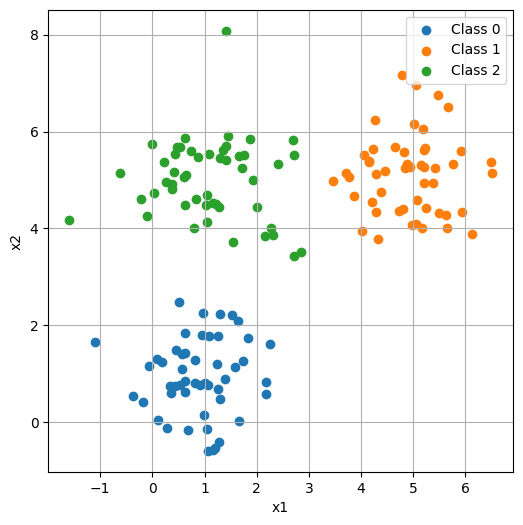

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
data_number = 150

X0 = np.random.randn(50, 2) * 0.8 + np.array([1, 1])
X1 = np.random.randn(50, 2) * 0.8 + np.array([5, 5])
X2 = np.random.randn(50, 2) * 0.8 + np.array([1, 5])

X = np.vstack([X0, X1, X2])
y = np.array([0]*50 + [1]*50 + [2]*50)

plt.figure(figsize=(6, 6))
for cls, label in zip([0, 1, 2], ["Class 0", "Class 1", "Class 2"]):
  mask = y == cls
  plt.scatter(X[mask, 0], X[mask, 1], label=label)
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

## 1.アルゴリズム

### 1.1.ジニ不純度

データの不確実性(混ざり具合)を表す指標。  
ジニ不純度 = 1 - Σ(p²)

### 1.2.情報利得

エントロピーの減少量を表す指標。これが最大になる分割を選ぶ。  
情報利得 = (分割前のジニ不純度) - (分割後のジニ不純度の加重平均)

### 1.3.再帰的なツリーの構築

最適な分割を見つけて、左右のノードに対して同じ処理を繰り返す。  
【終了条件】  
・深さの上限(max_depth)に達したとき  
・ノード内のデータ数が最小(min_samples_split)以下のとき  
・ノード内のデータが全て同じクラス(len(np.unique(y)) == 1)のとき

In [7]:
def gini(y):
  classes, counts = np.unique(y, return_counts=True)
  probs = counts / len(y)
  return 1 - np.sum(probs ** 2)

def most_common(y):
  classes, counts = np.unique(y, return_counts=True)
  return classes[np.argmax(counts)]

def information_gain(X_col, y, threshold):
  parent_gini = gini(y)

  left_mask = X_col <= threshold
  left_y  = y[left_mask]
  right_y = y[~left_mask]

  if len(left_y) == 0 or len(right_y) == 0:
    return 0

  n = len(y)
  child_gini = (len(left_y) / n) * gini(left_y) + (len(right_y) / n) * gini(right_y)

  return parent_gini - child_gini

def best_split(X, y):
  best_gain = -1
  best_feature = None
  best_threshold = None

  for feature in range(X.shape[1]):
    thresholds = np.unique(X[:, feature])
    for threshold in thresholds:
      gain = information_gain(X[:, feature], y, threshold)
      if gain > best_gain:
        best_gain = gain
        best_feature = feature
        best_threshold = threshold

  return best_feature, best_threshold

def build_tree(X, y, depth, max_depth=5, min_samples_split=2):
  n_samples = len(y)

  if depth >= max_depth or n_samples < min_samples_split or len(np.unique(y)) == 1:
    return {"leaf": True, "value": most_common(y)}

  best_feature, best_threshold = best_split(X, y)

  if best_feature is None:
    return {"leaf": True, "value": most_common(y)}

  left_mask = X[:, best_feature] <= best_threshold
  left_tree  = build_tree(X[left_mask],  y[left_mask],  depth + 1, max_depth, min_samples_split)
  right_tree = build_tree(X[~left_mask], y[~left_mask], depth + 1, max_depth, min_samples_split)

  return {
    "leaf": False,
    "feature": best_feature,
    "threshold": best_threshold,
    "left": left_tree,
    "right": right_tree
  }

def predict_one(x, node):
  if node["leaf"]:
    return node["value"]
  if x[node["feature"]] <= node["threshold"]:
    return predict_one(x, node["left"])
  else:
    return predict_one(x, node["right"])

def predict(X, tree):
  return np.array([predict_one(x, tree) for x in X])

## 2.モデルの可視化

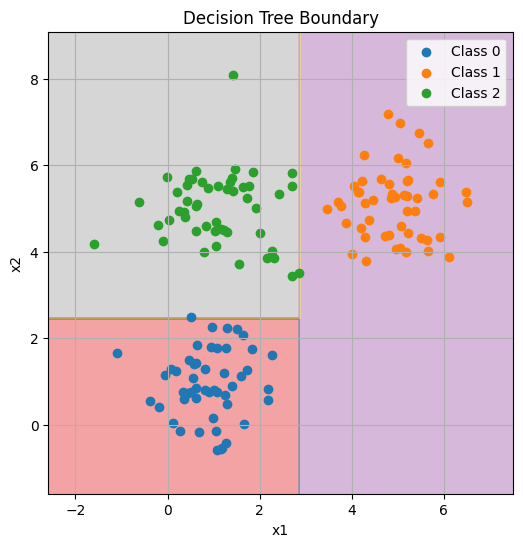

In [8]:
tree = build_tree(X, y, depth=0, max_depth=5)

x1_range = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
x2_range = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

grid = np.c_[X1_grid.ravel(), X2_grid.ravel()]
Z = predict(grid, tree).reshape(X1_grid.shape)

plt.figure(figsize=(6, 6))
plt.contourf(X1_grid, X2_grid, Z, alpha=0.4, cmap="Set1")
for cls, label in zip([0, 1, 2], ["Class 0", "Class 1", "Class 2"]):
  mask = y == cls
  plt.scatter(X[mask, 0], X[mask, 1], label=label)
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.title("Decision Tree Boundary")
plt.show()

## 3.検証

### 3.1.精度

In [10]:
tree = build_tree(X, y, depth=0, max_depth=5)
y_pred = predict(X, tree)
accuracy = np.sum(y_pred == y) / len(y)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


### 3.2.深さと精度のトレードオフ

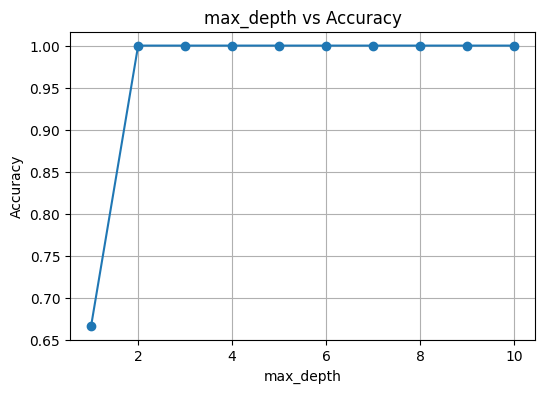

In [11]:
accuracies = []
depths = range(1, 11)

for max_depth in depths:
  tree = build_tree(X, y, depth=0, max_depth=max_depth)
  y_pred = predict(X, tree)
  accuracy = np.sum(y_pred == y) / len(y)
  accuracies.append(accuracy)

plt.figure(figsize=(6, 4))
plt.plot(depths, accuracies, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("max_depth vs Accuracy")
plt.grid(True)
plt.show()

### 3.3.混同行列

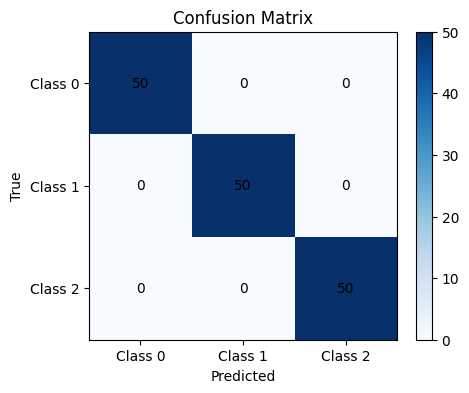

In [12]:
tree = build_tree(X, y, depth=0, max_depth=5)
y_pred = predict(X, tree)

n_classes = 3
cm = np.zeros((n_classes, n_classes), dtype=int)
for true, pred in zip(y, y_pred):
  cm[true][pred] += 1

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
for i in range(n_classes):
  for j in range(n_classes):
      plt.text(j, i, cm[i][j], ha="center", va="center", color="black")
plt.xticks([0, 1, 2], ["Class 0", "Class 1", "Class 2"])
plt.yticks([0, 1, 2], ["Class 0", "Class 1", "Class 2"])
plt.show()